In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('smartcart_customers.csv')
df.columns
#Handle missing values
df['Income'] = df['Income'].fillna(df['Income'].median())
df.isnull().sum()
df['Education'].value_counts()
df['Marital_Status'].value_counts()

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

Feature Engineering

In [ ]:
df['Age'] = 2026 - df['Year_Birth']
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_tenure_days'] = (reference_date - df['Dt_Customer']).dt.days
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Education'] = df['Education'].replace({
    'Basic': 'UnderGraduation', '2n Cycle': 'UnderGraduation',
    'PhD': 'PostGraduation', 'Master': 'PostGraduation'
})
df['Living_With'] = df['Marital_Status'].replace({
    'Married': 'Partner', 'Together': 'Partner',
    'Single': 'Alone', 'Divorced': 'Alone', 'Widow': 'Alone', 'Absurd': 'Alone', 'YOLO': 'Alone'
})

cols = ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_to_drop = cols + spending_cols
cleaned_df = df.drop(columns = cols_to_drop)
cleaned_df.sample(5)
# df['Education_Level'].value_counts()
# df['Living_With'].value_counts()

(2240, 15)

Outliers

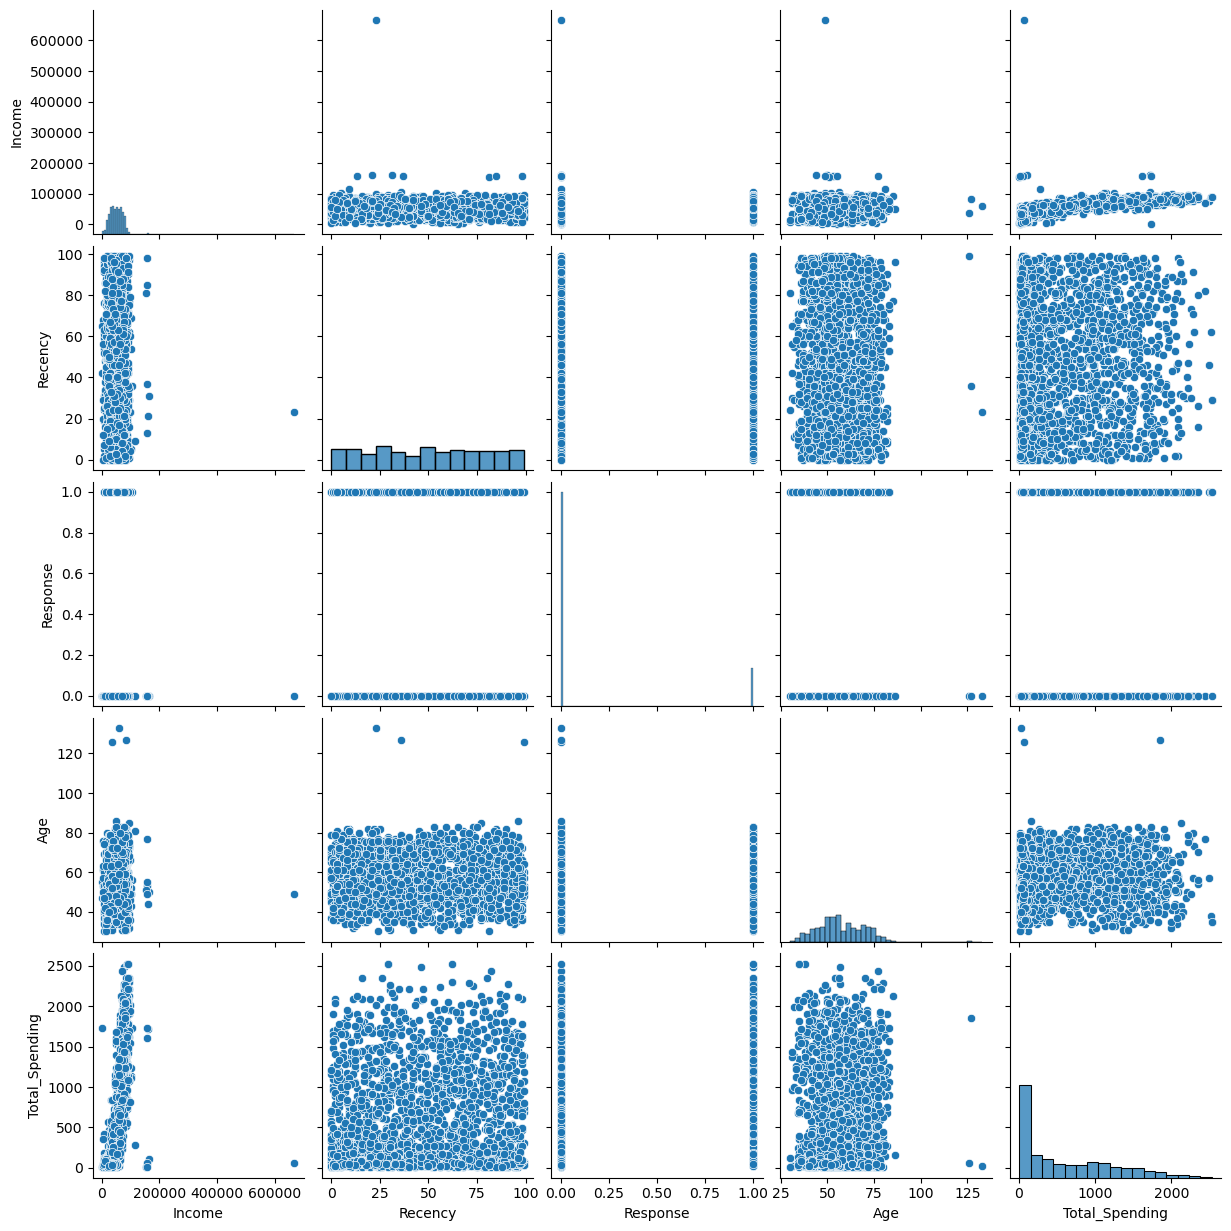

In [4]:
cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spending']

sns.pairplot(cleaned_df[cols])

In [5]:
print(f'before removing outliers: {len(cleaned_df)}')

cleaned_df = cleaned_df[ (cleaned_df['Income'] <  600_000) ]
cleaned_df = cleaned_df[ (cleaned_df['Age'] < 90) ]

print(f'After removing outliers: {len(cleaned_df)}')


before removing outliers: 2240
After removing outliers: 2236


Correlation

<Axes: >

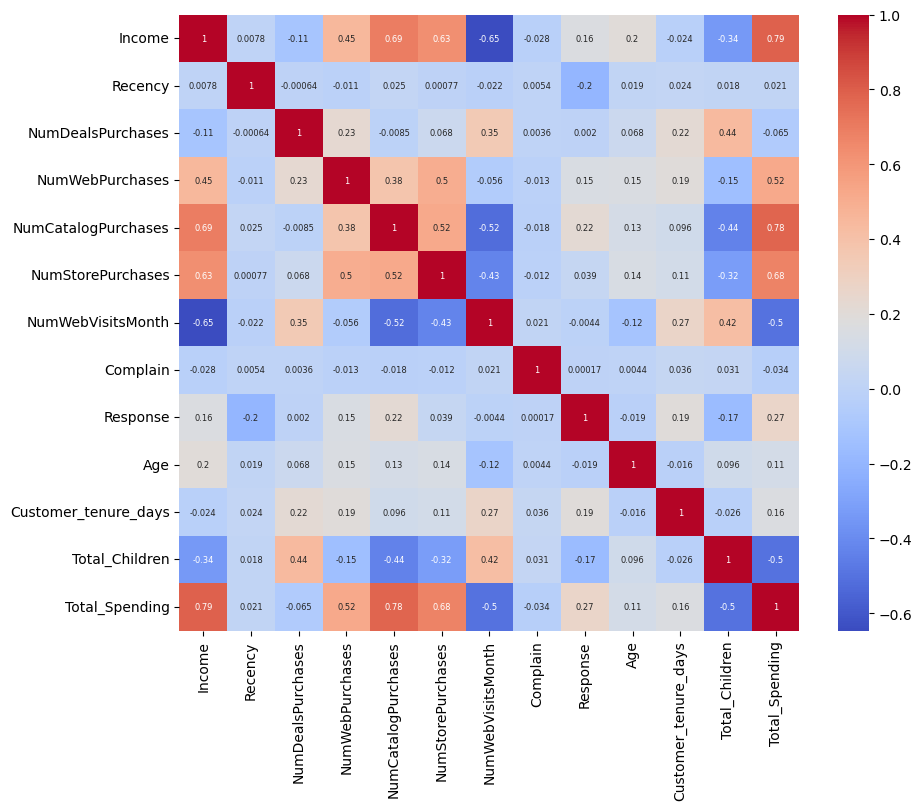

In [6]:
corr = cleaned_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size': 6},
    cmap='coolwarm'
)

In [7]:
# Correlation

# Income and Total_Spending
# Income and NumCatalogPurchases
# NumCatalogPurchases and Total_Spending
# NumStorePurcheses and Total_Spending

Encoding

In [8]:
ohe = OneHotEncoder()

cat_cols = ['Education', 'Living_With']
enc_cols = ohe.fit_transform(cleaned_df[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=cleaned_df.index)
encoded_df = pd.concat([cleaned_df.drop(columns=cat_cols), enc_df], axis=1)

Scaling and PCA

array([0.23163158, 0.11385454])

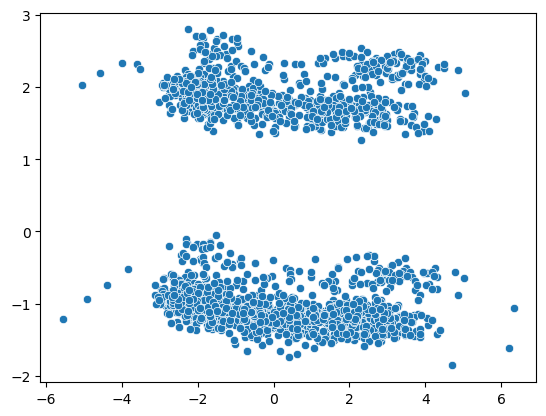

In [9]:
X = encoded_df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1])
pca.explained_variance_ratio_

Visualisation

In [10]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

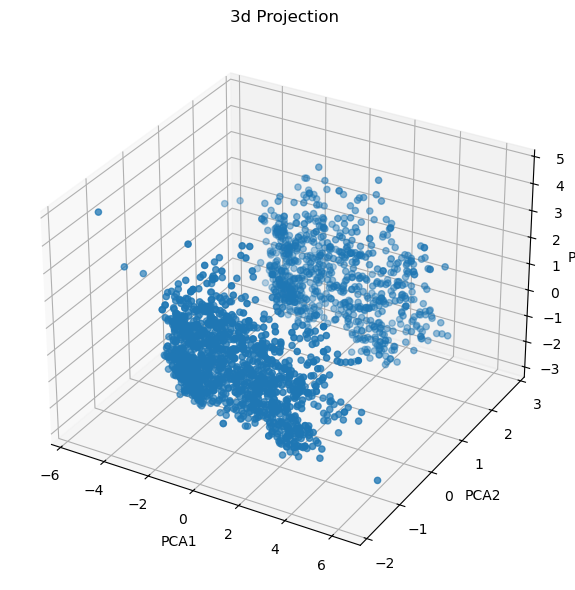

In [11]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3d Projection')
fig.tight_layout()

Elbow Method

4


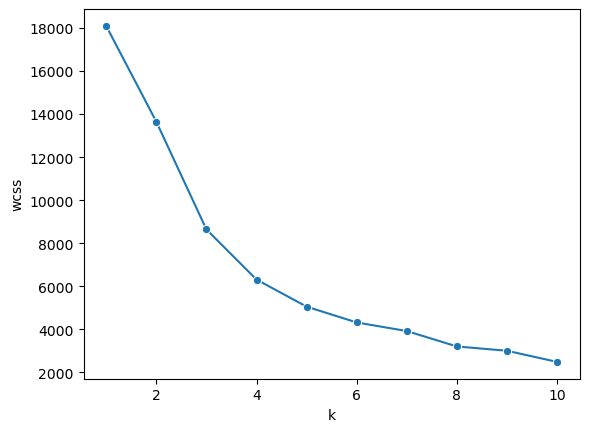

In [12]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,11), y=wcss, marker='o')
plt.xlabel('k')
plt.ylabel('wcss')
knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow
print(optimal_k)

silhouette Score Method

Text(0, 0.5, 'ss')

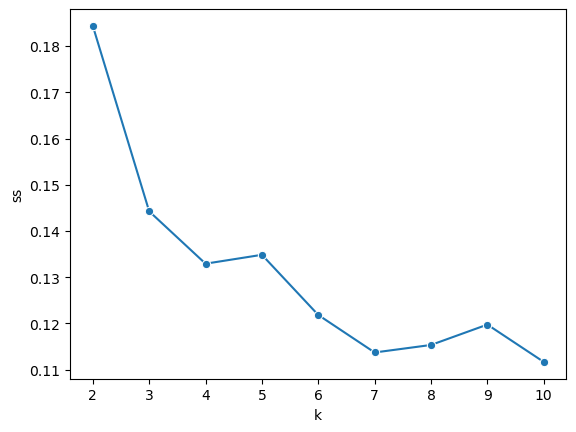

In [13]:
ss = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_scaled, labels)
    ss.append(score)

sns.lineplot(x=range(2,11), y=ss, marker='o')
# plt.plot(range(2,11), ss, marker='o')
plt.xlabel('k')
plt.ylabel('ss')

Combined Plots

Text(0, 0.5, 'SS')

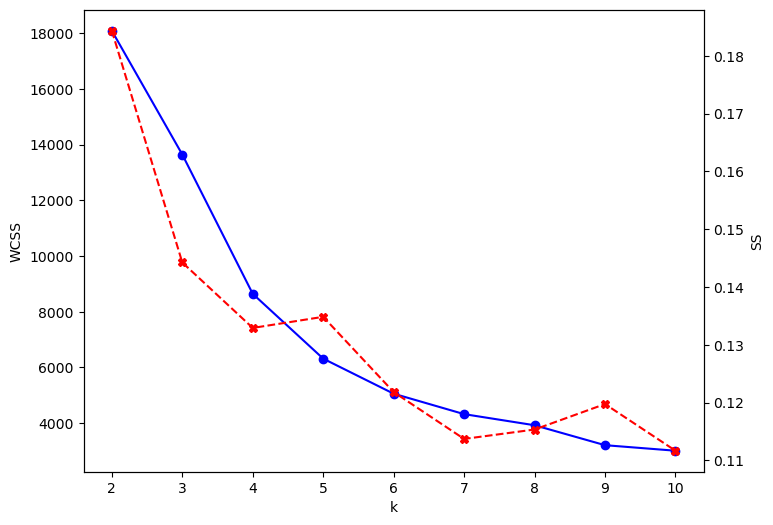

In [14]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[: len(k_range)], marker='o', color='blue')
ax1.set_xlabel('k')
ax1.set_ylabel('WCSS')

ax2 = ax1.twinx()
ax2.plot(k_range, ss[: len(k_range)], marker='X', color='red', linestyle='--')
ax2.set_xlabel('k')
ax2.set_ylabel('SS')

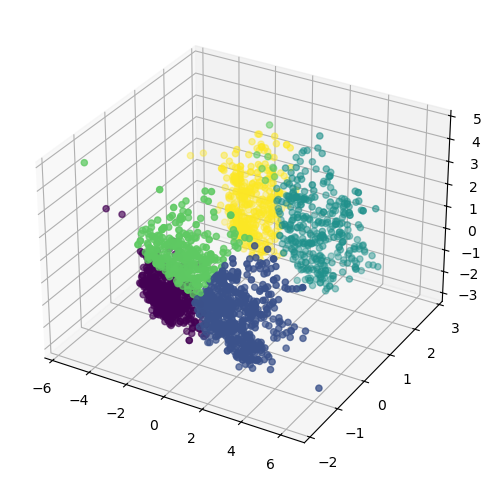

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)

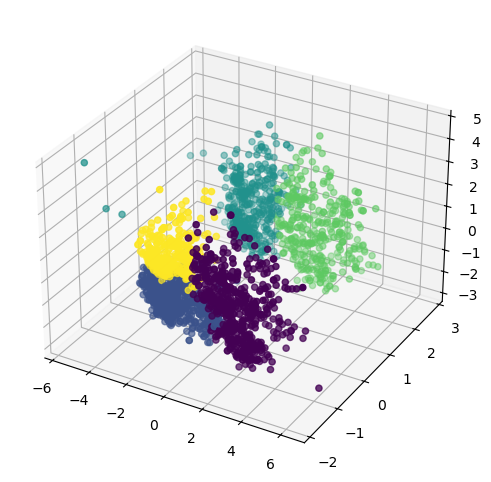

In [16]:
agg_cls = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_agg = agg_cls.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

Characterization of Clusters

<Axes: xlabel='cluster', ylabel='count'>

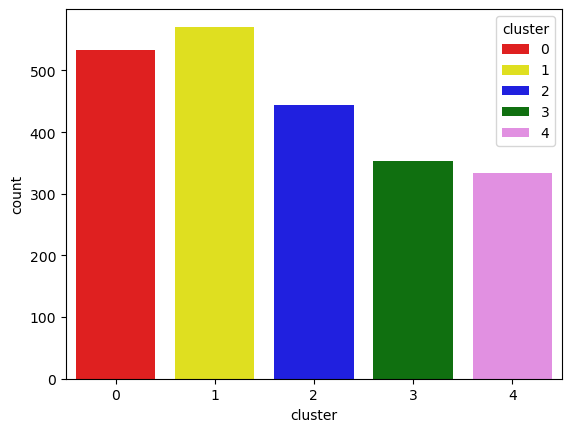

In [17]:
encoded_df['cluster'] = labels_agg

pal = ['red', 'yellow', 'blue', 'green', 'violet']

sns.countplot(x=encoded_df['cluster'], palette=pal, hue=encoded_df['cluster'])

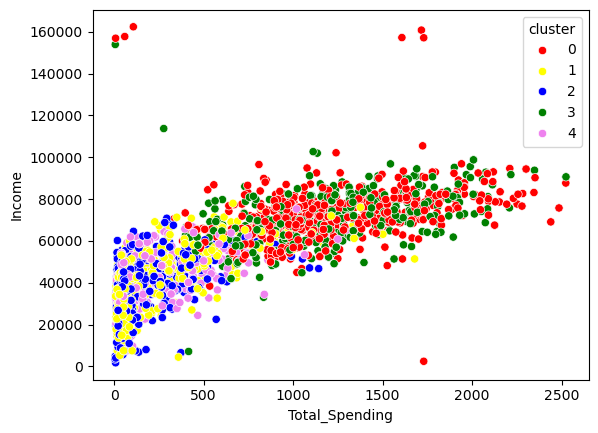

In [18]:
sns.scatterplot(x=encoded_df['Total_Spending'], y=encoded_df['Income'], hue=encoded_df['cluster'], palette=pal)
plt.savefig('final_clusters.png')

Clusters Summary

In [19]:
clusters_summary = encoded_df.groupby('cluster').mean()
print(clusters_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        72808.445693  49.202247           1.958801         5.687266   
1        38326.563923  50.828371           2.206655         2.887916   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   
4        41995.380240  45.643713           3.257485         3.607784   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   5.498127           8.659176           3.580524  0.005618   
1                   0.908932           4.105079           6.127846  0.017513   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   
4              